# SIH 2K26 — Ordinal DenseNet Training Pipeline

## Goal

This notebook trains and evaluates a **DenseNet-121 ordinal classification model** for the five severity grades:

- **Grade 0**
- **Grade 1**
- **Grade 2**
- **Grade 3**
- **Grade 4**

The model uses **ordinal regression** rather than treating the five grades as completely unrelated classes.

### What this notebook does

1. Detects the project and dataset paths automatically.
2. Loads the train/validation/test datasets.
3. Creates a pretrained DenseNet-121 backbone.
4. Adds a 4-output ordinal head.
5. Performs a short head-only warm-up.
6. Fine-tunes the backbone progressively.
7. Handles the severe class/threshold imbalance with `pos_weight`.
8. Uses a progress bar for batches and epochs.
9. Reports:
   - Loss
   - Accuracy
   - Macro F1
   - Quadratic Weighted Kappa (QWK)
   - MAE
   - Per-class precision/recall/F1
   - Confusion matrix
10. Saves the best checkpoint.
11. Evaluates the final model on the held-out test set.
12. Provides a single-image prediction helper.

> **Important:** 80% accuracy is a target, not something training can guarantee. For an imbalanced ordinal medical-image problem, QWK, macro F1, MAE and per-grade recall are also important. The notebook therefore tracks all of them instead of optimizing accuracy blindly.


## 1. Why QWK matters

**Quadratic Weighted Kappa (QWK)** measures agreement between the model's predicted ordinal grade and the true grade while penalizing larger mistakes more heavily.

For example:

- Predicting Grade 2 instead of Grade 3 → relatively small ordinal error.
- Predicting Grade 0 instead of Grade 4 → very large ordinal error.

QWK is particularly useful here because Grades 0–4 have a natural ordering.

Rough interpretation:

| QWK | Interpretation |
|---:|---|
| < 0 | Worse than chance |
| 0–0.20 | Very weak |
| 0.20–0.40 | Weak |
| 0.40–0.60 | Moderate |
| 0.60–0.80 | Good |
| 0.80–1.00 | Very strong |

These are practical guidelines, not universal clinical thresholds.

Your previous warm-up reached **Val QWK = 0.4109**, which means the model was learning useful ordinal structure, but it was still far from a strong final model.


In [1]:
# ============================================================
# 2. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    mean_absolute_error,
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)


/Users/sakshamchauhan/Downloads/SIH_Model/SIH/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0
Torchvision: 0.28.0


## 3. Device selection

On your Mac, PyTorch can use Apple's **MPS** backend.

The code below prefers:

1. MPS
2. CUDA
3. CPU

The model and image batches are always moved to the same device.


In [2]:
# ============================================================
# 3. DEVICE
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)
print("MPS available:", torch.backends.mps.is_available())
print("CUDA available:", torch.cuda.is_available())


Device: mps
MPS available: True
CUDA available: False


## 4. Locate the SIH dataset

Expected project structure:

```text
SIH_Model/
├── archive/
│   ├── train/
│   │   ├── 0/
│   │   ├── 1/
│   │   ├── 2/
│   │   ├── 3/
│   │   └── 4/
│   ├── val/
│   ├── test/
│   └── auto_test/
└── ...
```

The notebook searches common locations so that the checkpoint path does **not** accidentally point to the wrong directory.


In [3]:
# ============================================================
# 4. PROJECT / DATASET PATHS
# ============================================================

CANDIDATE_ROOTS = [
    Path("/Users/sakshamchauhan/Downloads/SIH_Model"),
    Path.cwd(),
]

PROJECT_ROOT = None

for root in CANDIDATE_ROOTS:
    if (root / "archive" / "train").exists():
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate SIH_Model/Osteoarthritis_Dataset/train. "
        "Set PROJECT_ROOT manually in this cell."
    )

DATASET_ROOT = PROJECT_ROOT / "Osteoarthritis_Dataset"

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"
AUTO_TEST_DIR = DATASET_ROOT / "auto_test"

OUTPUT_DIR = PROJECT_ROOT / "training_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CHECKPOINT = OUTPUT_DIR / "best_ordinal_densenet.pth"
LAST_CHECKPOINT = OUTPUT_DIR / "last_ordinal_densenet.pth"

print("Project root:", PROJECT_ROOT)
print("Dataset root:", DATASET_ROOT)
print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)
print("Auto-test:", AUTO_TEST_DIR)
print("Output:", OUTPUT_DIR)


Project root: /Users/sakshamchauhan/Downloads/SIH_Model
Dataset root: /Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset
Train: /Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset/train
Val: /Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset/val
Test: /Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset/test
Auto-test: /Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset/auto_test
Output: /Users/sakshamchauhan/Downloads/SIH_Model/training_outputs


## 5. Dataset and transforms

Training uses augmentation to reduce overfitting.

Validation/test data are **not randomly augmented** because evaluation should represent the model's real performance.

The ImageNet normalization is appropriate because the DenseNet-121 backbone starts from ImageNet pretrained weights.


In [4]:
# ============================================================
# 5. TRANSFORMS AND DATASETS
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print()
print("Dataset sizes:")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))


Classes: ['0', '1', '2']
Class mapping: {'0': 0, '1': 1, '2': 2}

Dataset sizes:
Train: 5778
Val  : 826
Test : 1656


## 6. Data loaders

`num_workers=0` is deliberately used for this Mac/Jupyter setup because it is robust and avoids multiprocessing issues.

The progress bar will now show the current batch, loss and approximate progress instead of appearing frozen for several minutes.


In [5]:
# ============================================================
# 6. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


Train batches: 723
Val batches  : 104
Test batches : 207


## 7. Ordinal encoding

Five grades require **four ordinal thresholds**:

- threshold 0: `grade > 0`
- threshold 1: `grade > 1`
- threshold 2: `grade > 2`
- threshold 3: `grade > 3`

Examples:

```text
Grade 0 -> [0, 0, 0, 0]
Grade 1 -> [1, 0, 0, 0]
Grade 2 -> [1, 1, 0, 0]
Grade 3 -> [1, 1, 1, 0]
Grade 4 -> [1, 1, 1, 1]
```

The network therefore outputs four logits instead of five unrelated class logits.


In [6]:
# ============================================================
# 7. ORDINAL TARGETS
# ============================================================

NUM_CLASSES = 3
NUM_THRESHOLDS = NUM_CLASSES - 1

def make_ordinal_targets(labels, num_classes=3):
    targets = torch.zeros(
        labels.size(0),
        num_classes - 1,
        device=labels.device,
        dtype=torch.float32,
    )

    for threshold in range(num_classes - 1):
        targets[:, threshold] = (labels > threshold).float()

    return targets


example_labels = torch.tensor([0, 1, 2])
print("Example labels:")
print(example_labels)
print()
print("Ordinal targets:")
print(make_ordinal_targets(example_labels))


Example labels:
tensor([0, 1, 2])

Ordinal targets:
tensor([[0., 0.],
        [1., 0.],
        [1., 1.]])


## 8. Class and threshold imbalance

Your dataset is highly imbalanced, especially for Grade 4.

The threshold `> 3` has only a small positive fraction.

If ordinary BCE is used without weighting, the model can get a deceptively good loss by favoring the majority negative class.

We therefore calculate **positive-class weights** for every ordinal threshold.

This is one of the main changes from the earlier warm-up.


In [7]:
# ============================================================
# 8. CLASS / THRESHOLD DISTRIBUTION
# ============================================================

train_labels = torch.tensor([label for _, label in train_dataset.samples])

class_counts = torch.bincount(
    train_labels,
    minlength=NUM_CLASSES
).numpy()

print("Training class distribution:")
for i, count in enumerate(class_counts):
    print(f"Grade {i}: {count}")

pos_counts = []
neg_counts = []

for threshold in range(NUM_THRESHOLDS):
    positives = int((train_labels > threshold).sum())
    negatives = int((train_labels <= threshold).sum())

    pos_counts.append(positives)
    neg_counts.append(negatives)

    ratio = positives / max(1, positives + negatives)

    print(
        f"Threshold > {threshold}: "
        f"positive={positives}, "
        f"negative={negatives}, "
        f"positive_ratio={ratio:.4f}"
    )

# BCEWithLogitsLoss pos_weight = negatives / positives
pos_weight = torch.tensor(
    [neg / max(pos, 1) for pos, neg in zip(pos_counts, neg_counts)],
    dtype=torch.float32,
    device=device,
)

print()
print("pos_weight:", pos_weight)


Training class distribution:
Grade 0: 2286
Grade 1: 2562
Grade 2: 930
Threshold > 0: positive=3492, negative=2286, positive_ratio=0.6044
Threshold > 1: positive=930, negative=4848, positive_ratio=0.1610

pos_weight: tensor([0.6546, 5.2129], device='mps:0')


## 9. DenseNet-121 ordinal model

The pretrained DenseNet-121 extracts a 1024-dimensional feature vector.

Only the final ordinal head is initially trained during warm-up.

After warm-up, the backbone is progressively unfrozen and fine-tuned using a smaller learning rate.

This prevents the pretrained representation from being destroyed too quickly.


In [8]:
# ============================================================
# 9. MODEL
# ============================================================

class OrdinalDenseNet(nn.Module):
    def __init__(self, num_features=1024, num_thresholds=4, dropout=0.3):
        super().__init__()

        weights = models.DenseNet121_Weights.DEFAULT
        backbone = models.densenet121(weights=weights)

        self.backbone = backbone
        self.backbone.classifier = nn.Identity()

        self.dropout = nn.Dropout(dropout)
        self.ordinal_head = nn.Linear(num_features, num_thresholds)

    def forward(self, x):
        features = self.backbone(x)
        features = self.dropout(features)
        logits = self.ordinal_head(features)
        return logits


model = OrdinalDenseNet(
    num_features=1024,
    num_thresholds=NUM_THRESHOLDS,
    dropout=0.3,
).to(device)

print(model)
print()
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters:",
      sum(p.numel() for p in model.parameters()))


OrdinalDenseNet(
  (backbone): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1

## 10. Ordinal loss and decoding

The loss is weighted `BCEWithLogitsLoss`.

Prediction works by applying sigmoid to the four threshold logits and counting how many thresholds are predicted positive.

For example:

```text
[positive, positive, negative, negative] -> Grade 2
```

We also calculate an optional monotonicity penalty. The ordinal probabilities should generally decrease as the threshold increases.


In [9]:
# ============================================================
# 10. LOSS + DECODING
# ============================================================

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def decode_ordinal_logits(logits):
    probs = torch.sigmoid(logits)
    predictions = (probs >= 0.5).sum(dim=1)
    return predictions.long(), probs

def ordinal_monotonicity_penalty(logits):
    probs = torch.sigmoid(logits)

    # Penalize p(threshold i+1) > p(threshold i)
    violation = torch.relu(probs[:, 1:] - probs[:, :-1])

    return violation.mean()


print("Loss:", criterion)
print("Thresholds:", NUM_THRESHOLDS)


Loss: BCEWithLogitsLoss()
Thresholds: 2


## 11. Metrics

The notebook tracks more than raw accuracy.

### Accuracy
Exact percentage of predictions that match the true grade.

### Macro F1
Computes F1 independently for each grade and averages them. This prevents the majority class from completely dominating the metric.

### QWK
Ordinal agreement metric. Larger mistakes receive larger penalties.

### MAE
Average absolute distance between predicted and actual grade.

For this problem, a model with 70% accuracy and excellent QWK/MAE may be more useful than a model with superficially higher accuracy that repeatedly confuses severe cases.


In [10]:
# ============================================================
# 11. METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred,
            labels=list(range(NUM_CLASSES)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true, y_pred,
            labels=list(range(NUM_CLASSES)),
            average="weighted",
            zero_division=0,
        ),
        "qwk": cohen_kappa_score(
            y_true,
            y_pred,
            weights="quadratic",
        ),
        "mae": mean_absolute_error(y_true, y_pred),
    }


def print_metrics(prefix, metrics):
    print(
        f"{prefix} | "
        f"Loss: {metrics['loss']:.4f} | "
        f"Acc: {metrics['accuracy']:.4f} | "
        f"Macro F1: {metrics['macro_f1']:.4f} | "
        f"QWK: {metrics['qwk']:.4f} | "
        f"MAE: {metrics['mae']:.4f}"
    )


## 12. Training and validation loops

Each epoch now has a `tqdm` progress bar.

At the end of every epoch we print:

- Train loss
- Validation loss
- Train accuracy
- Validation accuracy
- Train macro F1
- Validation macro F1
- Train QWK
- Validation QWK
- Train MAE
- Validation MAE

The checkpoint is selected using **validation QWK**, not training accuracy.


In [11]:
# ============================================================
# 12. TRAIN / VALIDATION FUNCTIONS
# ============================================================

def run_epoch(
    model,
    loader,
    optimizer=None,
    training=False,
    monotonic_weight=0.05,
    epoch_desc="Epoch",
):
    model.train(training)

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress = tqdm(
        loader,
        desc=epoch_desc,
        leave=True,
        dynamic_ncols=True,
    )

    for images, labels in progress:
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)

            ordinal_targets = make_ordinal_targets(labels)

            bce_loss = criterion(logits, ordinal_targets)
            mono_loss = ordinal_monotonicity_penalty(logits)

            loss = bce_loss + monotonic_weight * mono_loss

            if training:
                loss.backward()
                optimizer.step()

        predictions, _ = decode_ordinal_logits(logits)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        all_targets.extend(labels.detach().cpu().numpy().tolist())
        all_predictions.extend(predictions.detach().cpu().numpy().tolist())

        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)

    metric_values = calculate_metrics(
        all_targets,
        all_predictions,
    )

    metric_values["loss"] = epoch_loss

    return metric_values, all_targets, all_predictions


def save_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    best_qwk,
    history,
):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
            "best_qwk": best_qwk,
            "history": history,
        },
        path,
    )


# 13. Stage 1 — Head warm-up

Only the ordinal head is trainable.

This is useful because DenseNet-121 starts with useful pretrained image features, while the new ordinal head starts randomly initialized.

The earlier run achieved:

- Val Accuracy ≈ 38.7%
- Val QWK ≈ 0.411

We now continue into actual backbone fine-tuning with class/threshold weighting.


In [12]:
# ============================================================
# 13. FREEZE BACKBONE
# ============================================================

for param in model.backbone.parameters():
    param.requires_grad = False

for param in model.ordinal_head.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    model.ordinal_head.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

WARMUP_EPOCHS = 3

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_macro_f1": [],
    "val_macro_f1": [],
    "train_qwk": [],
    "val_qwk": [],
    "train_mae": [],
    "val_mae": [],
}

best_qwk = -np.inf

print("Starting head warm-up...")


Starting head warm-up...


In [13]:
# ============================================================
# DATASET STRUCTURE VALIDATION
# ============================================================

from pathlib import Path

DATA_ROOT = Path("/Users/sakshamchauhan/Downloads/SIH_Model/Osteoarthritis_Dataset")

for split in ["train", "val", "test"]:
    split_path = DATA_ROOT / split

    print("\n" + "=" * 70)
    print(f"{split.upper()} DATASET")
    print("=" * 70)

    if not split_path.exists():
        print(f"ERROR: {split_path} does not exist")
        continue

    total = 0

    for class_dir in sorted(split_path.iterdir()):
        if class_dir.is_dir():
            count = len([
                p for p in class_dir.iterdir()
                if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
            ])

            print(f"Class {class_dir.name}: {count} images")
            total += count

    print(f"TOTAL: {total}")


TRAIN DATASET
Class 0: 2286 images
Class 1: 2562 images
Class 2: 930 images
TOTAL: 5778

VAL DATASET
Class 0: 328 images
Class 1: 365 images
Class 2: 133 images
TOTAL: 826

TEST DATASET
Class 0: 639 images
Class 1: 743 images
Class 2: 274 images
TOTAL: 1656


In [14]:
# ============================================================
# 14. RUN WARM-UP
# ============================================================

for epoch in range(1, WARMUP_EPOCHS + 1):
    start = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        training=True,
        epoch_desc=f"Warm-up {epoch}/{WARMUP_EPOCHS} [TRAIN]",
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        optimizer=None,
        training=False,
        epoch_desc=f"Warm-up {epoch}/{WARMUP_EPOCHS} [VAL]",
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["train_qwk"].append(train_metrics["qwk"])
    history["val_qwk"].append(val_metrics["qwk"])
    history["train_mae"].append(train_metrics["mae"])
    history["val_mae"].append(val_metrics["mae"])

    if val_metrics["qwk"] > best_qwk:
        best_qwk = val_metrics["qwk"]
        save_checkpoint(
            BEST_CHECKPOINT,
            model,
            optimizer,
            epoch,
            best_qwk,
            history,
        )

    elapsed = time.time() - start

    print()
    print(f"Epoch {epoch}/{WARMUP_EPOCHS} | Time: {elapsed:.1f}s")
    print_metrics("TRAIN", train_metrics)
    print_metrics("VAL  ", val_metrics)
    print(f"Best validation QWK: {best_qwk:.4f}")
    print("-" * 80)

print("Warm-up complete.")
print("Best checkpoint:", BEST_CHECKPOINT)


Warm-up 1/3 [VAL]: 100%|██████████| 104/104 [00:13<00:00,  7.49it/s, loss=1.1887]



Epoch 1/3 | Time: 127.8s
TRAIN | Loss: 0.8261 | Acc: 0.4142 | Macro F1: 0.4050 | QWK: 0.2022 | MAE: 0.7094
VAL   | Loss: 0.7340 | Acc: 0.4988 | Macro F1: 0.4952 | QWK: 0.3628 | MAE: 0.5702
Best validation QWK: 0.3628
--------------------------------------------------------------------------------


Warm-up 2/3 [VAL]: 100%|██████████| 104/104 [00:12<00:00,  8.24it/s, loss=1.2142]



Epoch 2/3 | Time: 127.2s
TRAIN | Loss: 0.7847 | Acc: 0.4351 | Macro F1: 0.4262 | QWK: 0.2811 | MAE: 0.6807
VAL   | Loss: 0.7126 | Acc: 0.5048 | Macro F1: 0.5011 | QWK: 0.4015 | MAE: 0.5690
Best validation QWK: 0.4015
--------------------------------------------------------------------------------


Warm-up 3/3 [VAL]: 100%|██████████| 104/104 [00:13<00:00,  7.98it/s, loss=0.9681]



Epoch 3/3 | Time: 122.6s
TRAIN | Loss: 0.7828 | Acc: 0.4360 | Macro F1: 0.4277 | QWK: 0.2859 | MAE: 0.6727
VAL   | Loss: 0.7000 | Acc: 0.4867 | Macro F1: 0.4759 | QWK: 0.4178 | MAE: 0.5920
Best validation QWK: 0.4178
--------------------------------------------------------------------------------
Warm-up complete.
Best checkpoint: /Users/sakshamchauhan/Downloads/SIH_Model/training_outputs/best_ordinal_densenet.pth


# 15. Stage 2 — Progressive fine-tuning

Now we unfreeze the DenseNet backbone.

We use **discriminative learning rates**:

- New ordinal head: higher learning rate.
- DenseNet backbone: much smaller learning rate.

This lets the model adapt its visual representation without destroying pretrained features too aggressively.

The exact number of epochs is configurable below.


In [17]:
# ============================================================
# 16. UNFREEZE BACKBONE
# ============================================================

for param in model.backbone.parameters():
    param.requires_grad = True

for param in model.ordinal_head.parameters():
    param.requires_grad = True

BACKBONE_LR = 1e-5
HEAD_LR = 2e-4
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    [
        {
            "params": model.backbone.parameters(),
            "lr": BACKBONE_LR,
        },
        {
            "params": model.ordinal_head.parameters(),
            "lr": HEAD_LR,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
)

print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 6955906


## 17. Fine-tuning configuration

Start with 12 epochs.

If validation QWK/accuracy is still improving, increase the number of epochs rather than assuming the model has failed.

The scheduler automatically lowers learning rates when validation QWK stops improving.


In [18]:
# ============================================================
# 17. FINE-TUNING
# ============================================================

FINE_TUNE_EPOCHS = 15

# Restore the best QWK observed so far.
best_qwk = max(
    history["val_qwk"],
    default=-np.inf,
)

print("Starting fine-tuning...")
print("Best QWK before fine-tuning:", best_qwk)


Starting fine-tuning...
Best QWK before fine-tuning: 0.4178422679027274


In [19]:
# ============================================================
# 18. RUN FINE-TUNING
# ============================================================

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    start = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        training=True,
        monotonic_weight=0.05,
        epoch_desc=f"Fine-tune {epoch}/{FINE_TUNE_EPOCHS} [TRAIN]",
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        optimizer=None,
        training=False,
        monotonic_weight=0.05,
        epoch_desc=f"Fine-tune {epoch}/{FINE_TUNE_EPOCHS} [VAL]",
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["train_qwk"].append(train_metrics["qwk"])
    history["val_qwk"].append(val_metrics["qwk"])
    history["train_mae"].append(train_metrics["mae"])
    history["val_mae"].append(val_metrics["mae"])

    scheduler.step(val_metrics["qwk"])

    if val_metrics["qwk"] > best_qwk:
        best_qwk = val_metrics["qwk"]

        save_checkpoint(
            BEST_CHECKPOINT,
            model,
            optimizer,
            WARMUP_EPOCHS + epoch,
            best_qwk,
            history,
        )

        best_marker = " <-- BEST"
    else:
        best_marker = ""

    save_checkpoint(
        LAST_CHECKPOINT,
        model,
        optimizer,
        WARMUP_EPOCHS + epoch,
        best_qwk,
        history,
    )

    elapsed = time.time() - start
    current_lrs = [group["lr"] for group in optimizer.param_groups]

    print()
    print(
        f"Fine-tune Epoch {epoch}/{FINE_TUNE_EPOCHS} "
        f"| Time: {elapsed:.1f}s"
    )
    print_metrics("TRAIN", train_metrics)
    print_metrics("VAL  ", val_metrics)
    print(f"Learning rates: {current_lrs}")
    print(f"Best validation QWK: {best_qwk:.4f}{best_marker}")
    print("-" * 80)

print()
print("=" * 80)
print("FINE-TUNING COMPLETE")
print("=" * 80)
print("Best validation QWK:", best_qwk)
print("Best checkpoint:", BEST_CHECKPOINT)


Fine-tune 1/15 [VAL]: 100%|██████████| 104/104 [00:12<00:00,  8.17it/s, loss=0.6200]



Fine-tune Epoch 1/15 | Time: 317.6s
TRAIN | Loss: 0.6512 | Acc: 0.5057 | Macro F1: 0.4982 | QWK: 0.4374 | MAE: 0.5632
VAL   | Loss: 0.5185 | Acc: 0.5835 | Macro F1: 0.5831 | QWK: 0.5645 | MAE: 0.4552
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.5645 <-- BEST
--------------------------------------------------------------------------------


Fine-tune 2/15 [VAL]: 100%|██████████| 104/104 [00:13<00:00,  7.99it/s, loss=0.7222]



Fine-tune Epoch 2/15 | Time: 338.8s
TRAIN | Loss: 0.5244 | Acc: 0.5720 | Macro F1: 0.5764 | QWK: 0.5600 | MAE: 0.4593
VAL   | Loss: 0.4576 | Acc: 0.5993 | Macro F1: 0.6029 | QWK: 0.5778 | MAE: 0.4395
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.5778 <-- BEST
--------------------------------------------------------------------------------


Fine-tune 3/15 [VAL]: 100%|██████████| 104/104 [00:12<00:00,  8.00it/s, loss=0.2502]


...


Fine-tune Epoch 13/15 | Time: 317.9s
TRAIN | Loss: 0.2870 | Acc: 0.7376 | Macro F1: 0.7570 | QWK: 0.7542 | MAE: 0.2648
VAL   | Loss: 0.3723 | Acc: 0.6937 | Macro F1: 0.7128 | QWK: 0.7084 | MAE: 0.3111
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.7187
--------------------------------------------------------------------------------


Fine-tune 14/15 [VAL]: 100%|██████████| 104/104 [00:14<00:00,  6.98it/s, loss=0.0261]



Fine-tune Epoch 14/15 | Time: 352.0s
TRAIN | Loss: 0.2728 | Acc: 0.7416 | Macro F1: 0.7628 | QWK: 0.7554 | MAE: 0.2612
VAL   | Loss: 0.3897 | Acc: 0.6985 | Macro F1: 0.7139 | QWK: 0.7160 | MAE: 0.3087
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.7187
--------------------------------------------------------------------------------


Fine-tune 15/15 [VAL]: 100%|██████████| 104/104 [00:13<00:00,  7.98it/s, loss=0.0324]



Fine-tune Epoch 15/15 | Time: 500.6s
TRAIN | Loss: 0.2813 | Acc: 0.7319 | Macro F1: 0.7541 | QWK: 0.7483 | MAE: 0.2707
VAL   | Loss: 0.3568 | Acc: 0.7070 | Macro F1: 0.7281 | QWK: 0.7279 | MAE: 0.2966
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.7279 <-- BEST
--------------------------------------------------------------------------------

FINE-TUNING COMPLETE
Best validation QWK: 0.7278693516673623
Best checkpoint: /Users/sakshamchauhan/Downloads/SIH_Model/training_outputs/best_ordinal_densenet.pth


# 19. Training curves

These plots make it much easier to determine whether the model is:

- still learning,
- overfitting,
- underfitting,
- or plateauing.

A large train/validation gap usually indicates overfitting.


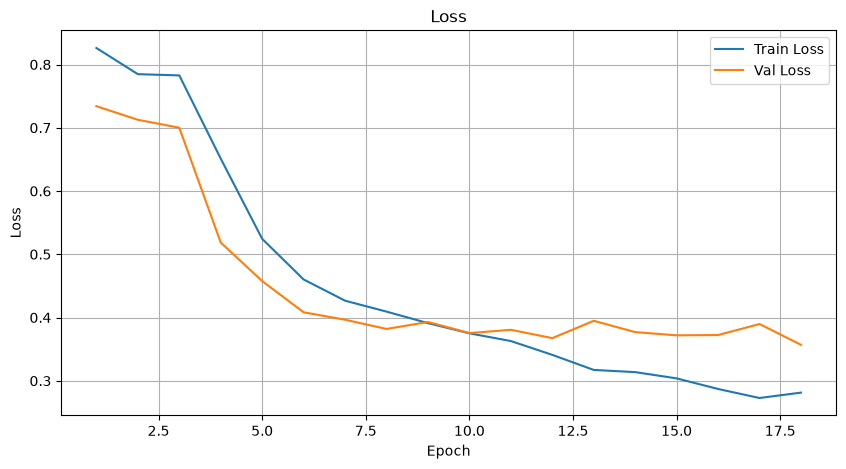

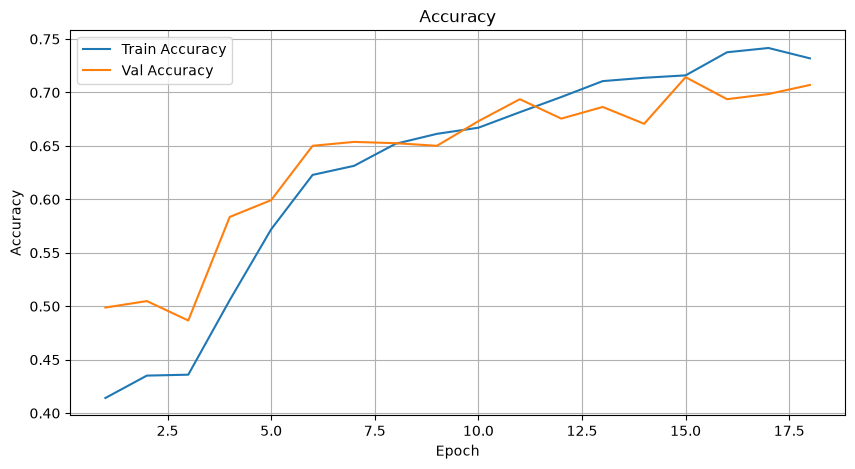

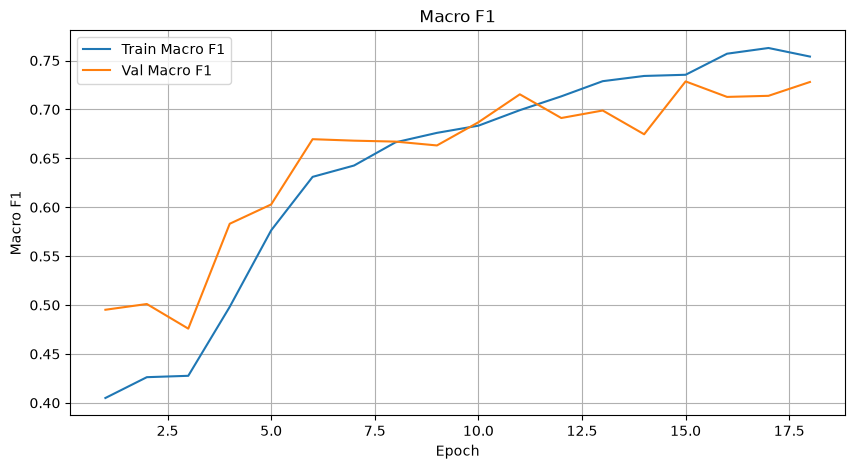

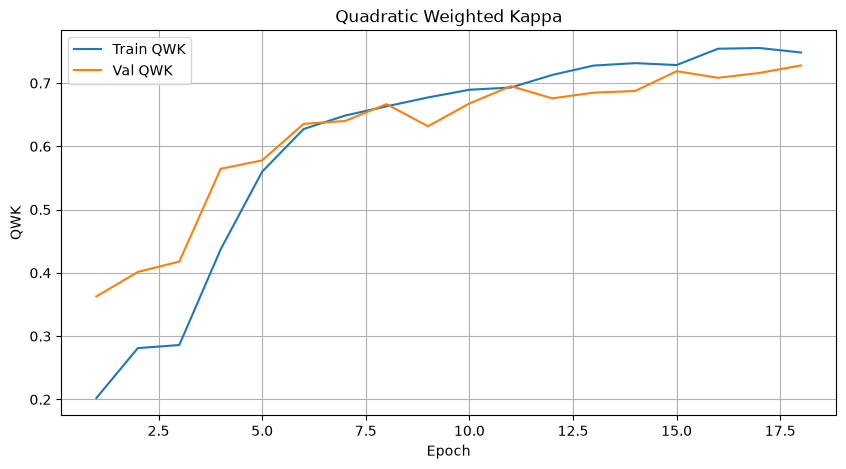

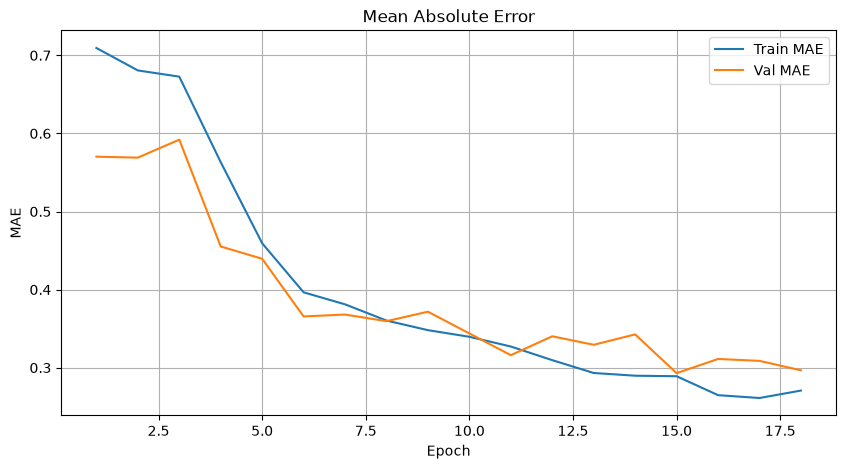

In [20]:
# ============================================================
# 19. PLOT TRAINING HISTORY
# ============================================================

epochs = np.arange(1, len(history["train_loss"]) + 1)

fig = plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_macro_f1"], label="Train Macro F1")
plt.plot(epochs, history["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_qwk"], label="Train QWK")
plt.plot(epochs, history["val_qwk"], label="Val QWK")
plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.title("Quadratic Weighted Kappa")
plt.legend()
plt.grid(True)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_mae"], label="Train MAE")
plt.plot(epochs, history["val_mae"], label="Val MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Mean Absolute Error")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# ============================================================
# 18. RUN FINE-TUNING
# ============================================================

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    start = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        training=True,
        monotonic_weight=0.05,
        epoch_desc=f"Fine-tune {epoch}/{FINE_TUNE_EPOCHS} [TRAIN]",
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        optimizer=None,
        training=False,
        monotonic_weight=0.05,
        epoch_desc=f"Fine-tune {epoch}/{FINE_TUNE_EPOCHS} [VAL]",
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["train_qwk"].append(train_metrics["qwk"])
    history["val_qwk"].append(val_metrics["qwk"])
    history["train_mae"].append(train_metrics["mae"])
    history["val_mae"].append(val_metrics["mae"])

    scheduler.step(val_metrics["qwk"])

    if val_metrics["qwk"] > best_qwk:
        best_qwk = val_metrics["qwk"]

        save_checkpoint(
            BEST_CHECKPOINT,
            model,
            optimizer,
            WARMUP_EPOCHS + epoch,
            best_qwk,
            history,
        )

        best_marker = " <-- BEST"
    else:
        best_marker = ""

    save_checkpoint(
        LAST_CHECKPOINT,
        model,
        optimizer,
        WARMUP_EPOCHS + epoch,
        best_qwk,
        history,
    )

    elapsed = time.time() - start
    current_lrs = [group["lr"] for group in optimizer.param_groups]

    print()
    print(
        f"Fine-tune Epoch {epoch}/{FINE_TUNE_EPOCHS} "
        f"| Time: {elapsed:.1f}s"
    )
    print_metrics("TRAIN", train_metrics)
    print_metrics("VAL  ", val_metrics)
    print(f"Learning rates: {current_lrs}")
    print(f"Best validation QWK: {best_qwk:.4f}{best_marker}")
    print("-" * 80)

print()
print("=" * 80)
print("FINE-TUNING COMPLETE")
print("=" * 80)
print("Best validation QWK:", best_qwk)
print("Best checkpoint:", BEST_CHECKPOINT)


Fine-tune 1/15 [VAL]: 100%|██████████| 104/104 [00:14<00:00,  6.96it/s, loss=0.0214]



Fine-tune Epoch 1/15 | Time: 397.0s
TRAIN | Loss: 0.2524 | Acc: 0.7548 | Macro F1: 0.7800 | QWK: 0.7697 | MAE: 0.2465
VAL   | Loss: 0.3809 | Acc: 0.6973 | Macro F1: 0.7206 | QWK: 0.7009 | MAE: 0.3087
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.7279
--------------------------------------------------------------------------------


Fine-tune 2/15 [VAL]: 100%|██████████| 104/104 [00:14<00:00,  7.38it/s, loss=0.0382]



Fine-tune Epoch 2/15 | Time: 355.5s
TRAIN | Loss: 0.2579 | Acc: 0.7546 | Macro F1: 0.7788 | QWK: 0.7657 | MAE: 0.2480
VAL   | Loss: 0.3786 | Acc: 0.7094 | Macro F1: 0.7279 | QWK: 0.7132 | MAE: 0.2978
Learning rates: [1e-05, 0.0002]
Best validation QWK: 0.7279
--------------------------------------------------------------------------------


Fine-tune 3/15 [VAL]: 100%|██████████| 104/104 [00:13<00:00,  7.52it/s, loss=0.0323]


...


Fine-tune Epoch 13/15 | Time: 349.4s
TRAIN | Loss: 0.1856 | Acc: 0.8124 | Macro F1: 0.8378 | QWK: 0.8201 | MAE: 0.1885
VAL   | Loss: 0.4699 | Acc: 0.7361 | Macro F1: 0.7540 | QWK: 0.7327 | MAE: 0.2700
Learning rates: [2.5e-06, 5e-05]
Best validation QWK: 0.7372
--------------------------------------------------------------------------------


Fine-tune 14/15 [VAL]: 100%|██████████| 104/104 [00:14<00:00,  7.42it/s, loss=0.0181]



Fine-tune Epoch 14/15 | Time: 344.2s
TRAIN | Loss: 0.1713 | Acc: 0.8157 | Macro F1: 0.8444 | QWK: 0.8235 | MAE: 0.1847
VAL   | Loss: 0.4702 | Acc: 0.7373 | Macro F1: 0.7607 | QWK: 0.7337 | MAE: 0.2676
Learning rates: [2.5e-06, 5e-05]
Best validation QWK: 0.7372
--------------------------------------------------------------------------------


Fine-tune 15/15 [VAL]: 100%|██████████| 104/104 [00:15<00:00,  6.91it/s, loss=0.0172]



Fine-tune Epoch 15/15 | Time: 437.3s
TRAIN | Loss: 0.1734 | Acc: 0.8178 | Macro F1: 0.8459 | QWK: 0.8258 | MAE: 0.1824
VAL   | Loss: 0.5190 | Acc: 0.7228 | Macro F1: 0.7468 | QWK: 0.7149 | MAE: 0.2845
Learning rates: [2.5e-06, 5e-05]
Best validation QWK: 0.7372
--------------------------------------------------------------------------------

FINE-TUNING COMPLETE
Best validation QWK: 0.7371737516419501
Best checkpoint: /Users/sakshamchauhan/Downloads/SIH_Model/training_outputs/best_ordinal_densenet.pth


# 20. Load the best validation checkpoint

Never automatically use the final epoch.

The best checkpoint is the epoch that achieved the highest validation QWK.


In [22]:
# ============================================================
# 20. LOAD BEST MODEL
# ============================================================

if not BEST_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Best checkpoint was not created: {BEST_CHECKPOINT}"
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print("Loaded best model.")
print("Best epoch:", best_checkpoint["epoch"])
print("Best validation QWK:", best_checkpoint["best_qwk"])


Loaded best model.
Best epoch: 8
Best validation QWK: 0.7371737516419501


# 21. Detailed validation report

This gives the detailed view you requested.

The classification report shows performance for each individual grade.

For this problem, pay special attention to **Grades 3 and 4**. A model that achieves high overall accuracy by mostly predicting Grades 0–2 can still be poor at detecting severe cases.


In [23]:
# ============================================================
# 21. VALIDATION REPORT
# ============================================================

val_metrics, val_true, val_pred = run_epoch(
    model,
    val_loader,
    optimizer=None,
    training=False,
    monotonic_weight=0.05,
    epoch_desc="Final Validation",
)

print()
print("=" * 80)
print("VALIDATION METRICS")
print("=" * 80)
print_metrics("VAL", val_metrics)

print()
print("Classification report:")
print(
    classification_report(
        val_true,
        val_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=[f"Grade {i}" for i in range(NUM_CLASSES)],
        digits=4,
        zero_division=0,
    )
)


Final Validation: 100%|██████████| 104/104 [00:14<00:00,  7.35it/s, loss=0.0284]



VALIDATION METRICS
VAL | Loss: 0.3907 | Acc: 0.7312 | Macro F1: 0.7525 | QWK: 0.7372 | MAE: 0.2736

Classification report:
              precision    recall  f1-score   support

     Grade 0     0.6835    0.8232    0.7469       328
     Grade 1     0.7616    0.5863    0.6625       365
     Grade 2     0.8000    0.9023    0.8481       133

    accuracy                         0.7312       826
   macro avg     0.7484    0.7706    0.7525       826
weighted avg     0.7368    0.7312    0.7259       826



Validation confusion matrix:
[[270  57   1]
 [122 214  29]
 [  3  10 120]]


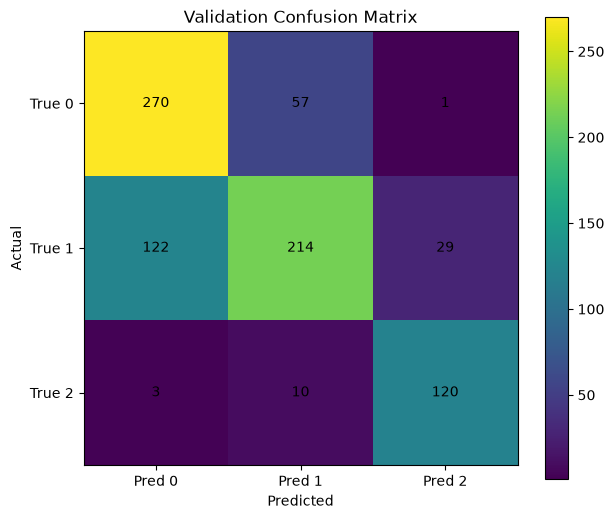

In [24]:
# ============================================================
# 22. VALIDATION CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    val_true,
    val_pred,
    labels=list(range(NUM_CLASSES)),
)

print("Validation confusion matrix:")
print(cm)

fig = plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.xticks(range(NUM_CLASSES), [f"Pred {i}" for i in range(NUM_CLASSES)])
plt.yticks(range(NUM_CLASSES), [f"True {i}" for i in range(NUM_CLASSES)])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Confusion Matrix")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# 23. Final test evaluation

The test set should be treated as the final held-out evaluation.

Do not use test performance to choose hyperparameters. Hyperparameters should be selected using the training/validation sets.


In [25]:
# ============================================================
# 23. TEST EVALUATION
# ============================================================

test_metrics, test_true, test_pred = run_epoch(
    model,
    test_loader,
    optimizer=None,
    training=False,
    monotonic_weight=0.05,
    epoch_desc="Final Test",
)

print()
print("=" * 80)
print("FINAL TEST RESULTS")
print("=" * 80)
print_metrics("TEST", test_metrics)

print()
print("Test classification report:")
print(
    classification_report(
        test_true,
        test_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=[f"Grade {i}" for i in range(NUM_CLASSES)],
        digits=4,
        zero_division=0,
    )
)


Final Test: 100%|██████████| 207/207 [00:31<00:00,  6.64it/s, loss=0.3038]


FINAL TEST RESULTS
TEST | Loss: 0.3023 | Acc: 0.7736 | Macro F1: 0.7867 | QWK: 0.7865 | MAE: 0.2283

Test classification report:
              precision    recall  f1-score   support

     Grade 0     0.7294    0.8732    0.7949       639
     Grade 1     0.8237    0.6353    0.7173       743
     Grade 2     0.7893    0.9161    0.8480       274

    accuracy                         0.7736      1656
   macro avg     0.7808    0.8082    0.7867      1656
weighted avg     0.7816    0.7736    0.7689      1656



Test confusion matrix:
[[558  79   2]
 [206 472  65]
 [  1  22 251]]


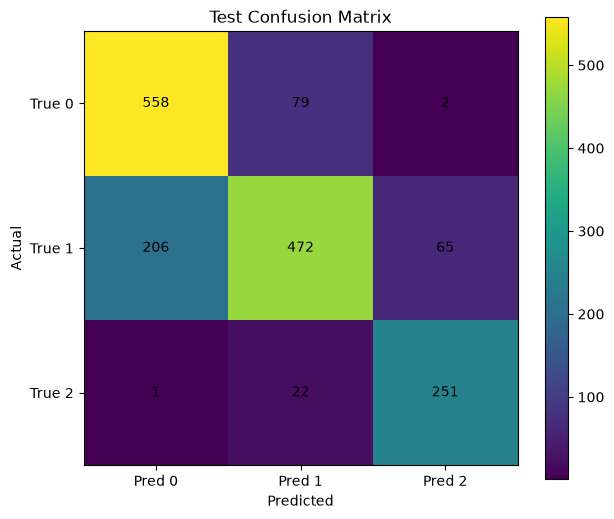

In [26]:
# ============================================================
# 24. TEST CONFUSION MATRIX
# ============================================================

test_cm = confusion_matrix(
    test_true,
    test_pred,
    labels=list(range(NUM_CLASSES)),
)

print("Test confusion matrix:")
print(test_cm)

fig = plt.figure(figsize=(7, 6))
plt.imshow(test_cm)
plt.xticks(range(NUM_CLASSES), [f"Pred {i}" for i in range(NUM_CLASSES)])
plt.yticks(range(NUM_CLASSES), [f"True {i}" for i in range(NUM_CLASSES)])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Confusion Matrix")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, test_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# 25. Single-image prediction

This helper can be used by the SIH application later.

It returns:

- predicted grade,
- four threshold probabilities,
- confidence-like information.

### Important

The threshold probabilities are not automatically a calibrated clinical confidence score. Calibration should be evaluated separately before presenting them as probabilities to users.


In [27]:
# ============================================================
# 25. SINGLE IMAGE PREDICTION
# ============================================================

from PIL import Image

def predict_image(image_path, model=model):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    tensor = eval_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        prediction, probabilities = decode_ordinal_logits(logits)

    grade = int(prediction.item())
    threshold_probs = probabilities[0].detach().cpu().numpy()

    return {
        "predicted_grade": grade,
        "threshold_probabilities": threshold_probs,
        "logits": logits[0].detach().cpu().numpy(),
    }


# Example:
# result = predict_image("/path/to/image.jpg")
# print(result)


# 26. What to do if accuracy is still below 80%

Do **not** immediately increase loss weights or force the model to predict 80%.

Instead, use the validation report to diagnose the problem.

### If training accuracy is low AND validation accuracy is low
The model is underfitting.

Possible actions:

- train for more epochs,
- increase the learning rate slightly,
- unfreeze more of the backbone,
- reduce excessive augmentation.

### If training accuracy is high but validation accuracy is low
The model is overfitting.

Possible actions:

- stronger augmentation,
- dropout,
- weight decay,
- lower learning rate,
- early stopping,
- more data.

### If Grade 4 recall is poor
This is especially important for the project.

Possible actions:

- threshold weighting,
- class-aware sampling,
- targeted augmentation,
- focal/ordinal loss experiments,
- collecting more Grade 4 examples.

### If QWK improves while accuracy does not
That is not necessarily bad.

It can mean the model is learning the ordinal structure and making nearby mistakes rather than catastrophic mistakes.

---

## Recommended target hierarchy

For this project I would monitor:

1. **Validation QWK**
2. **Validation Macro F1**
3. **Grade 3/4 recall**
4. **Validation MAE**
5. **Validation accuracy**

An 80% accuracy target is worth pursuing, but it should not come at the expense of severe-class detection.

---

## Current baseline

Your previous warm-up ended at approximately:

- Train Accuracy: **35.1%**
- Validation Accuracy: **38.7%**
- Train QWK: **0.325**
- Validation QWK: **0.411**
- Validation MAE: **0.845**

That is a valid starting point, not the final model.

The next stage in this notebook specifically addresses the major weaknesses:

- pretrained backbone fine-tuning,
- threshold imbalance weighting,
- monotonic ordinal regularization,
- progressive learning rates,
- scheduler,
- detailed validation metrics,
- checkpointing,
- progress bars.


# 27. Optional: save metrics to CSV

This makes it easy to include quantitative training results in the SIH presentation/report.


In [28]:
# ============================================================
# 27. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_csv = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv, index=False)

print("Saved:", history_csv)


Saved: /Users/sakshamchauhan/Downloads/SIH_Model/training_outputs/training_history.csv
